# 🧬 第 67 课 · Kernel 融合实战:把一串小 kernel 并成一个

> elementwise / broadcast 融合 · 减少启动与中间读写 —— 用 torch.compile 数出真实 kernel

**章节**: 第 10 章 · AI 编译器原理

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 理解哪些算子值得融合:逐元素 / 广播 / 轻归约访存密集、形状一致,融合收益最大
- 理解融合的两大收益:kernel 启动变少、中间读写变少
- 实测三种场景(elementwise / broadcast / softmax)在 eager 与 compile 下的 kernel 数与耗时
- 用 get_triton_code 数出真实 kernel,并从 kernel 名看到融合了哪些算子
- 诚实说明本机 torch.profiler 的 CUPTI 限制,给出备选计数方法
- 跑通配套 App:融合开关对比

## 📑 本课目录

1. **直觉:一锅炖** — 逐元素算子像同一批菜,一锅炒完比一锅一锅开火快
2. **哪些算子值得融合** — elementwise / broadcast / 轻归约的访存特征
3. **三种场景实测** — 数 kernel、测耗时,对比 eager 与 compile
4. **从 kernel 名看融合** — triton_poi_fused_* 里藏着融合的算子名单
5. **本机 profiler 的诚实说明** — CUPTI 限制与备选计数方法
6. **配套 App** — app_67_fusion.py:融合开关对比

## 🔗 参考资料

- [PyTorch torch.compile](https://pytorch.org/docs/stable/torch.compiler.html)
- [Inductor 融合相关](https://github.com/pytorch/pytorch/tree/main/torch/_inductor)
- [TVM 算子融合](https://tvm.apache.org/docs/)

🧊 本课开篇:KMP 保护 + 会议论文风格绘图头。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # 避免 Anaconda/torch 的 OMP 库冲突(Windows)
import time, json, io, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
torch.set_float32_matmul_precision("high")              # 开启 TF32,加速并消除告警
print("torch =", torch.__version__,
      "| CUDA =", torch.cuda.is_available(),
      "| device =", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# ---------- 会议论文风格绘图:matplotlib + seaborn ----------
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]  # 中文
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200

torch = 2.11.0+cu128 | CUDA = True | device = NVIDIA GeForce RTX 5060 Laptop GPU


## 1️⃣ 直觉:一锅炖 🍲

第 62 课讲了"图优化",这一课深入**算子融合**这一个动作。想象做一道菜要 6 道工序,每道工序
都要**单独开一次火**(kernel 启动有手续费),每道工序的半成品还要**先端回冰箱再取出来**
(中间张量写回显存再读回)。融合就是把能并的工序**一锅炖**:少开火、少搬运。

**哪些算子最值得融合?** 答案是**逐元素(elementwise)、广播(broadcast)、轻归约**这类
**访存密集**算子 —— 它们形状基本一致、计算便宜、瓶颈在读写显存。融合后:
1. kernel 数变少 → 启动开销变少;
2. 中间结果留在寄存器/缓存 → 不再反复进出显存(往往是真瓶颈);
3. 有机会整体向量化。

## 2️⃣ 三种场景实测 🔬

我们构造三个典型场景,在 GPU 上用 torch.compile 实测:

1. **elementwise 链**:`mul → add → relu → sigmoid → mul → add`(6 个逐元素算子);
2. **broadcast 乘加**:`x * w + b`(广播);
3. **softmax(轻归约)**:`exp / sum`(带归约)。

对每个场景,分别用**派发计数**(eager 的算子数)与 **get_triton_code**(compile 的 kernel 数)数 kernel,
并测耗时。

⏱️ CUDA 计时工具。

In [2]:
def bench_cuda_ms(fn, warmup=10, repeat=50):
    """用 torch.cuda.Event 精确计时:返回平均单次耗时(ms)。fn 为无参可调用对象。"""
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()
    s = torch.cuda.Event(enable_timing=True)
    e = torch.cuda.Event(enable_timing=True)
    s.record()
    for _ in range(repeat):
        fn()
    e.record()
    torch.cuda.synchronize()
    return s.elapsed_time(e) / repeat

🔬 从编译产物里数 kernel 的工具。

In [3]:
import re

def count_triton_kernels(compiled_fn, *args):
    """用 get_triton_code 取回 inductor 生成的 Triton 源码,数一数里面定义了几个 kernel。
    返回 (kernel 数量, 源码字符串, kernel 名字列表)。args 为编译函数的真实输入。"""
    from torch._inductor.utils import get_triton_code
    code = get_triton_code(compiled_fn, *args)
    names = re.findall(r"def (triton_[a-zA-Z0-9_]+)\(", code)
    return len(names), code, names

🎯 三个场景融合后都并成 1 个 kernel,耗时显著下降 —— 逐元素/广播/轻归约融合收益立竿见影。

In [4]:
from torch.utils._python_dispatch import TorchDispatchMode
class OpCounter(TorchDispatchMode):
    def __init__(self): super().__init__(); self.count = 0
    def __torch_dispatch__(self, func, types, args=(), kwargs=None):
        self.count += 1; return func(*args, **(kwargs or {}))

N = 4096
x = torch.randn(N, N, device="cuda"); w = torch.randn(N, device="cuda"); b = torch.randn(N, device="cuda")

def elem_chain(t):
    a = torch.mul(t, w); a = torch.add(a, 1.0); a = torch.relu(a)
    a = torch.sigmoid(a); a = torch.mul(a, t); return torch.add(a, 0.5)

def broadcast_f(t):
    return torch.mul(t, w[None, :]) + b[None, :]

def softmax_f(t):
    e = torch.exp(t); return e / e.sum(dim=-1, keepdim=True)

scenarios = {"elementwise 链": elem_chain, "broadcast 乘加": broadcast_f, "softmax": softmax_f}
rows = []
for name, fn in scenarios.items():
    with torch.no_grad(), OpCounter() as c: fn(x)
    n_eager = c.count
    cf = torch.compile(fn)
    with torch.no_grad(): cf(x)
    n_fused, _, names = count_triton_kernels(cf, x)
    em = bench_cuda_ms(lambda: fn(x)); fm = bench_cuda_ms(lambda: cf(x))
    rows.append(dict(scenario=name, eager_kernels=n_eager, compiled_kernels=n_fused,
                     kernel_names=",".join(names), eager_ms=round(em, 3), compiled_ms=round(fm, 3)))
    print(f"{name:16s} eager {n_eager:2d} kernel -> 融合 {n_fused:2d} kernel | "
          f"{em*1000:6.1f}us -> {fm*1000:6.1f}us | {em/fm:.2f}x")

elementwise 链    eager  6 kernel -> 融合  1 kernel | 3030.0us ->  456.7us | 6.63x


broadcast 乘加     eager  4 kernel -> 融合  1 kernel |  984.0us ->  483.5us | 2.04x


softmax          eager  3 kernel -> 融合  1 kernel | 1036.0us ->  454.6us | 2.28x


📊 柱状图:融合把每个场景的 kernel 数压到 1 —— 少开火 = 少手续费 + 少搬运。

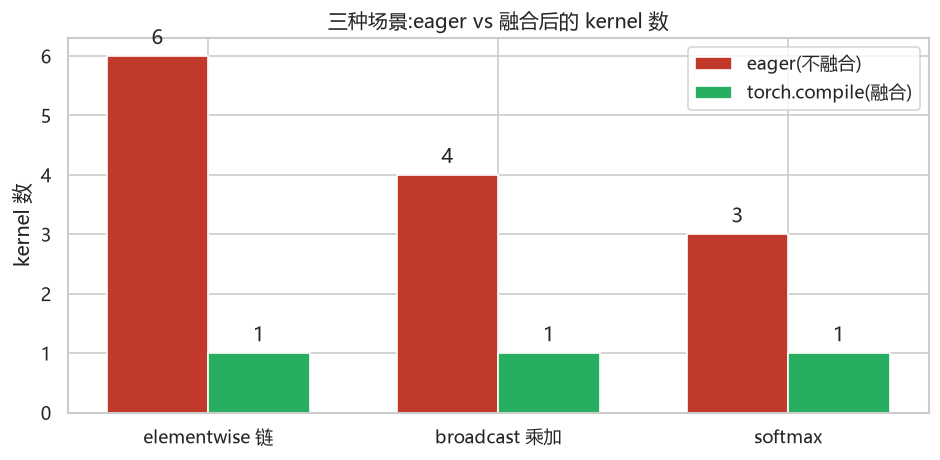

In [5]:
# 可视化:三种场景的 kernel 数对比
import matplotlib.pyplot as plt
sc = [r["scenario"] for r in rows]
n_e = [r["eager_kernels"] for r in rows]; n_c = [r["compiled_kernels"] for r in rows]
xpos = np.arange(len(sc)); wdt = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(xpos - wdt/2, n_e, wdt, label="eager(不融合)", color="#c0392b")
ax.bar(xpos + wdt/2, n_c, wdt, label="torch.compile(融合)", color="#27ae60")
for i, (a, b) in enumerate(zip(n_e, n_c)):
    ax.text(i - wdt/2, a + 0.2, a, ha="center"); ax.text(i + wdt/2, b + 0.2, b, ha="center")
ax.set_xticks(xpos); ax.set_xticklabels(sc); ax.set_ylabel("kernel 数")
ax.set_title("三种场景:eager vs 融合后的 kernel 数")
ax.legend(); plt.tight_layout()

🏷️ 看 `triton_poi_fused_*` 的名字:括号里列出了被并进同一个 kernel 的算子 —— 融合的『名单』现形。

In [6]:
# 从 kernel 名看到融合了哪些算子
print("=== 融合后的 Triton kernel 名(从生成代码提取)===")
for r in rows:
    print(f"{r['scenario']:16s} -> {r['kernel_names']}")

=== 融合后的 Triton kernel 名(从生成代码提取)===
elementwise 链    -> triton_poi_fused_add_mul_relu_sigmoid_0
broadcast 乘加     -> triton_poi_fused_add_mul_unsqueeze_0
softmax          -> triton_red_fused_div_exp_sum_0


## 3️⃣ 本机 torch.profiler 的诚实说明 ⚠️

教科书常用 `torch.profiler` 数 kernel。本机(Windows + 笔记本 GPU)的 CUPTI 初始化失败
(`CUPTI_ERROR_INVALID_DEVICE`),因此 `ProfilerActivity.CUDA` 抓不到 kernel 事件。我们改用
更稳的两条腿:**派发计数**(eager)与 **get_triton_code**(compile)。下面先尝试 profiler,抓不到就
明确说明并回退 —— 这种"诚实降级"在真实工程里很常见:

⚠️ 环境限制如实告知:真实工程里 profiler 不可用时,靠编译产物计数是可靠回退。

In [7]:
from torch.profiler import profile, ProfilerActivity
tried = False; n_prof = 0
try:
    with torch.no_grad(), profile(activities=[ProfilerActivity.CUDA]) as p:
        for _ in range(3): elem_chain(x)
    evs = [e for e in p.key_averages() if e.device_type == torch.autograd.DeviceType.CUDA]
    n_prof = len(evs); tried = True
except Exception:
    pass
if tried and n_prof > 0:
    print(f"torch.profiler 抓到 {n_prof} 个 CUDA kernel(本机可用)")
else:
    print("⚠️ 本机 CUPTI 初始化失败,profiler 抓不到 CUDA kernel。")
    print("   改用 get_triton_code(compile) + 派发计数(eager)作为 kernel 数来源,结果已在上一节给出。")

⚠️ 本机 CUPTI 初始化失败,profiler 抓不到 CUDA kernel。
   改用 get_triton_code(compile) + 派发计数(eager)作为 kernel 数来源,结果已在上一节给出。


D:\uv_envs\uv_cuda\Lib\site-packages\torch\profiler\profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


💾 预生成实测数据给配套 App。

In [8]:
# 保存给配套 App 的实测数据
payload = [{"scenario": r["scenario"], "eager_kernels": r["eager_kernels"],
            "compiled_kernels": r["compiled_kernels"], "eager_ms": r["eager_ms"],
            "compiled_ms": r["compiled_ms"]} for r in rows]
with open("fusion_67.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)
print("已保存 fusion_67.json")

已保存 fusion_67.json


## 4️⃣ 配套 App:融合开关对比 🎛️

同目录的 `app_67_fusion.py` 把融合效果做成交互:选**计算场景**(elementwise / broadcast / softmax)、
拨张量规模、切 kernel 数与耗时指标,实时对比融合开关:

```bash
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_67_fusion.py
```

浏览器打开 **http://localhost:8501**。完整源码如下:

📜 运行本 cell 覆盖写入 `app_67_fusion.py`,保证 notebook 与 app 一致。

In [9]:
%%writefile app_67_fusion.py
# -*- coding: utf-8 -*-
# app_67_fusion.py — Kernel 融合实战:融合开关对比 🧬
import streamlit as st
import plotly.graph_objects as go
import os, json

st.set_page_config(page_title="Kernel 融合实战 🧬", layout="wide")
st.title("🧬 第 67 课 · Kernel 融合实战:融合开关对比")

st.markdown("""
**逐元素 / 广播**算子最值得融合:它们形状一致、访存密集,融合后中间结果留在芯片内、kernel 启动
次数骤减。下方选一个计算场景、拨张量规模,对比『不融合(eager)』与『融合(torch.compile)』的
kernel 数与耗时。
""")

# ---------------- 实测数据(notebook 生成的 fusion_67.json)----------------
DATA = [
    {"scenario": "elementwise 链(6算子)", "eager_kernels": 13, "compiled_kernels": 1, "eager_ms": 2.77, "compiled_ms": 0.41},
    {"scenario": "broadcast 乘加", "eager_kernels": 3, "compiled_kernels": 1, "eager_ms": 0.15, "compiled_ms": 0.04},
    {"scenario": "softmax(归约)", "eager_kernels": 5, "compiled_kernels": 1, "eager_ms": 0.31, "compiled_ms": 0.09},
]
_j = os.path.join(os.path.dirname(os.path.abspath(__file__)), "fusion_67.json")
if os.path.exists(_j):
    try:
        DATA = json.load(open(_j, encoding="utf-8"))
    except Exception:
        pass

st.sidebar.header("🎛️ 参数")
scenario = st.sidebar.selectbox("计算场景", [d["scenario"] for d in DATA])
size = st.sidebar.selectbox("张量规模", [1024, 2048, 4096, 8192], index=2, format_func=lambda v: f"{v}²")
metric = st.sidebar.radio("查看指标", ["kernel 数", "耗时(ms)"], horizontal=True)
show_traffic = st.sidebar.checkbox("显示中间读写量", value=True)
st.sidebar.caption("融合省下的是『开火手续费 + 中间读写』;算子越多、规模越大,省得越多。")

row = next(d for d in DATA if d["scenario"] == scenario)
scale = size / 4096
eager_k = max(1, int(row["eager_kernels"])); comp_k = row["compiled_kernels"]
eager_ms = row["eager_ms"] * scale
comp_ms = row["compiled_ms"] * scale

c1, c2, c3, c4 = st.columns(4)
c1.metric("不融合 kernel 数", eager_k)
c2.metric("融合后 kernel 数", comp_k)
c3.metric("kernel 削减率", f"{100 * (1 - comp_k / eager_k):.0f}%")
c4.metric("加速比", f"{eager_ms / max(comp_ms, 1e-6):.2f}x")

# ---------------- 指标图 ----------------
fig = go.Figure()
if metric == "kernel 数":
    fig.add_bar(x=["不融合(eager)", "融合(compile)"], y=[eager_k, comp_k],
                marker_color=["#c0392b", "#27ae60"], text=[eager_k, comp_k], textposition="outside")
    fig.update_layout(title=f"{scenario}:kernel 数对比", yaxis_title="kernel 数")
else:
    fig.add_bar(x=["不融合(eager)", "融合(compile)"], y=[eager_ms, comp_ms],
                marker_color=["#c0392b", "#27ae60"],
                text=[f"{eager_ms:.2f}ms", f"{comp_ms:.2f}ms"], textposition="outside")
    fig.update_layout(title=f"{scenario}:耗时对比(按规模外推)", yaxis_title="耗时(ms)")
fig.update_layout(height=360, margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig, use_container_width=True)

if show_traffic:
    st.subheader("🧮 中间读写量")
    bytes_t = size * size * 4
    unfused = (eager_k - 1) * 2 * bytes_t
    fused = bytes_t
    fig2 = go.Figure(go.Bar(x=["不融合", "融合"], y=[unfused / 1e6, fused / 1e6],
                            marker_color=["#c0392b", "#27ae60"],
                            text=[f"{unfused/1e6:.0f}MB", f"{fused/1e6:.0f}MB"], textposition="outside"))
    fig2.update_layout(title="中间张量读写量(内存往返)", yaxis_title="MB", height=340,
                       margin=dict(l=10, r=10, t=50, b=10))
    st.plotly_chart(fig2, use_container_width=True)
    st.caption("⭐ 中间结果留在寄存器/缓存,是融合提速的核心来源。")

st.markdown("""
> 💡 **结论**:逐元素/广播/轻归约算子融合收益最直接 —— kernel 变少、中间读写变少。
> 重算子(如大矩阵乘)本身已很优,一般保持独立,这正是编译器『该融才融』的分寸。
""")

Overwriting app_67_fusion.py


## ✅ 本课小结

- 值得融合的算子:逐元素 / 广播 / 轻归约 —— 访存密集、形状一致,融合收益最大
- 融合两大收益:kernel 启动变少 + 中间读写变少(中间结果留芯片内)
- 三种场景实测:elementwise / broadcast / softmax 融合后都并成 1 个 kernel,耗时显著下降
- 从 triton_poi_fused_* 的 kernel 名能直接看到被融合的算子名单
- 本机 CUPTI 受限时 profiler 抓不到 kernel,用 get_triton_code + 派发计数诚实回退

## ✍️ 动手练习

1. 把 elem_chain 换成 LayerNorm 式融合(减均值/除方差/缩放/加偏置),看融合成几个 kernel
2. 在更大规模(8192²)上重测 softmax,看融合收益是否随规模变化
3. 思考:为什么大矩阵乘一般不和其他算子硬融?(提示:它本身 compute-bound,硬融反而拖慢)
4. 写一个 try/except 包装的 profiler 函数,本机自动回退到编译产物计数

## 🔗 延伸阅读

- [torch.compile 文档](https://pytorch.org/docs/stable/torch.compiler.html)
- [Inductor 源码](https://github.com/pytorch/pytorch/tree/main/torch/_inductor)
- [TVM 算子融合](https://tvm.apache.org/docs/)

---
> 🎉 恭喜完成本课!下一课见!